# 04 — Transfer Learning: VGG16 & ResNet50
ImageNet ağırlıklı modeller — 2 aşamalı eğitim (dondur → fine-tune).

In [1]:
import sys, os
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path

from models import build_vgg16, build_resnet50, unfreeze_for_finetune
from preprocessing import make_generator_minimal, make_generator_clahe
from evaluate import evaluate_model, append_metrics_csv

DATA_DIR    = Path('../data/chest_xray/chest_xray')
RESULTS_DIR = Path('../results')
FIGURES_DIR = RESULTS_DIR / 'figures'
METRICS_CSV = str(RESULTS_DIR / 'metrics.csv')

os.makedirs(str(FIGURES_DIR), exist_ok=True)

TRAIN_DIR = str(DATA_DIR / 'train')
VAL_DIR   = str(DATA_DIR / 'val')
TEST_DIR  = str(DATA_DIR / 'test')

BATCH_SIZE      = 32
EPOCHS_FROZEN   = 10
EPOCHS_FINETUNE = 5

In [2]:
def train_transfer_model(build_fn, model_name, gen_fn, preprocessing):
    print(f'\n=== {model_name} | {preprocessing} ===')
    train_gen = gen_fn(TRAIN_DIR, augment=True,  batch_size=BATCH_SIZE)
    val_gen   = gen_fn(VAL_DIR,   augment=False, batch_size=BATCH_SIZE, shuffle=False)
    test_gen  = gen_fn(TEST_DIR,  augment=False, batch_size=BATCH_SIZE, shuffle=False)

    model = build_fn()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy'],
    )

    frozen_cb = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7),
    ]

    print('-- Dondurulmuş aşama --')
    history_frozen = model.fit(
        train_gen, validation_data=val_gen,
        epochs=EPOCHS_FROZEN, callbacks=frozen_cb,
    )

    print('-- Fine-tune aşaması --')
    unfreeze_for_finetune(model)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-5),
        loss='binary_crossentropy',
        metrics=['accuracy'],
    )
    ft_cb = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint(
            f'../results/{model_name}_{preprocessing}_best.keras',
            monitor='val_loss', save_best_only=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7),
    ]
    history_ft = model.fit(
        train_gen, validation_data=val_gen,
        epochs=EPOCHS_FINETUNE, callbacks=ft_cb,
    )

    metrics = evaluate_model(model, test_gen, model_name, preprocessing)
    append_metrics_csv(metrics, METRICS_CSV)
    return model, history_frozen, history_ft, metrics

## VGG16 — Minimal Önişleme

In [3]:
vgg16_min_model, vgg16_min_hist_f, vgg16_min_hist_ft, vgg16_min_metrics = \
    train_transfer_model(build_vgg16, 'vgg16', make_generator_minimal, 'minimal')


=== vgg16 | minimal ===
Found 5216 images belonging to 2 classes.
Found 538 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 112s 2us/step
-- Dondurulmuş aşama --
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 240s 1s/step - accuracy: 0.7320 - loss: 0.5473 - val_accuracy: 0.7379 - val_loss: 0.4574 - learning_rate: 1.0000e-04
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 254s 2s/step - accuracy: 0.7947 - loss: 0.4227 - val_accuracy: 0.8457 - val_loss: 0.3780 - learning_rate: 1.0000e-04
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - accuracy: 0.8426 - loss: 0.3527 - val_accuracy: 0.8792 - val_loss: 0.3275 - learning_rate: 1.0000e-04
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 238s 1s/step - accuracy: 0.8681 - loss: 0.3113 - val_accuracy: 0.8941 - val_loss: 0.2979 - learning_rate: 1.0000e-04
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 226s 1s/step - accuracy: 0.8832 - loss: 0.2842 - val_accuracy: 0.8903 - val_loss: 0.2783 - learning_rate: 

## VGG16 — CLAHE Önişleme

In [4]:
vgg16_cl_model, vgg16_cl_hist_f, vgg16_cl_hist_ft, vgg16_cl_metrics = \
    train_transfer_model(build_vgg16, 'vgg16', make_generator_clahe, 'clahe')


=== vgg16 | clahe ===
Found 5216 images belonging to 2 classes.
Found 538 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
-- Dondurulmuş aşama --
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 239s 1s/step - accuracy: 0.7373 - loss: 0.5528 - val_accuracy: 0.7361 - val_loss: 0.4996 - learning_rate: 1.0000e-04
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 224s 1s/step - accuracy: 0.7613 - loss: 0.4656 - val_accuracy: 0.7695 - val_loss: 0.4355 - learning_rate: 1.0000e-04
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 226s 1s/step - accuracy: 0.8106 - loss: 0.4006 - val_accuracy: 0.8327 - val_loss: 0.3830 - learning_rate: 1.0000e-04
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 225s 1s/step - accuracy: 0.8443 - loss: 0.3529 - val_accuracy: 0.8736 - val_loss: 0.3484 - learning_rate: 1.0000e-04
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step - accuracy: 0.8710 - loss: 0.3161 - val_accuracy: 0.8792 - val_loss: 0.3260 - learning_rate: 1.0000e-04
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 242s

## ResNet50 — Minimal Önişleme

In [5]:
rn50_min_model, rn50_min_hist_f, rn50_min_hist_ft, rn50_min_metrics = \
    train_transfer_model(build_resnet50, 'resnet50', make_generator_minimal, 'minimal')


=== resnet50 | minimal ===
Found 5216 images belonging to 2 classes.
Found 538 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 74s 1us/step
-- Dondurulmuş aşama --
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 130s 772ms/step - accuracy: 0.7264 - loss: 0.5922 - val_accuracy: 0.7361 - val_loss: 0.5504 - learning_rate: 1.0000e-04
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 124s 759ms/step - accuracy: 0.7444 - loss: 0.5496 - val_accuracy: 0.7361 - val_loss: 0.5271 - learning_rate: 1.0000e-04
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 122s 747ms/step - accuracy: 0.7458 - loss: 0.5208 - val_accuracy: 0.7379 - val_loss: 0.5091 - learning_rate: 1.0000e-04
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 122s 747ms/step - accuracy: 0.7475 - loss: 0.5080 - val_accuracy: 0.7379 - val_loss: 0.4907 - learning_rate: 1.0000e-04
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 122s 746ms/step - accuracy: 0.7535 - loss: 0.4871 - val_accuracy: 0.7398 - val_loss: 0.4770 

## ResNet50 — CLAHE Önişleme

In [6]:
rn50_cl_model, rn50_cl_hist_f, rn50_cl_hist_ft, rn50_cl_metrics = \
    train_transfer_model(build_resnet50, 'resnet50', make_generator_clahe, 'clahe')


=== resnet50 | clahe ===
Found 5216 images belonging to 2 classes.
Found 538 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
-- Dondurulmuş aşama --
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 136s 810ms/step - accuracy: 0.7268 - loss: 0.5785 - val_accuracy: 0.7361 - val_loss: 0.5152 - learning_rate: 1.0000e-04
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 130s 794ms/step - accuracy: 0.7536 - loss: 0.5006 - val_accuracy: 0.7454 - val_loss: 0.4686 - learning_rate: 1.0000e-04
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 129s 791ms/step - accuracy: 0.7648 - loss: 0.4634 - val_accuracy: 0.7955 - val_loss: 0.4492 - learning_rate: 1.0000e-04
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 129s 787ms/step - accuracy: 0.7795 - loss: 0.4369 - val_accuracy: 0.8011 - val_loss: 0.4213 - learning_rate: 1.0000e-04
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 129s 788ms/step - accuracy: 0.7949 - loss: 0.4243 - val_accuracy: 0.8048 - val_loss: 0.4076 - learning_rate: 1.0000e-04
Epoch 6/10
163/163 ━━━━━━━

## Loss Eğrileri Karşılaştırması

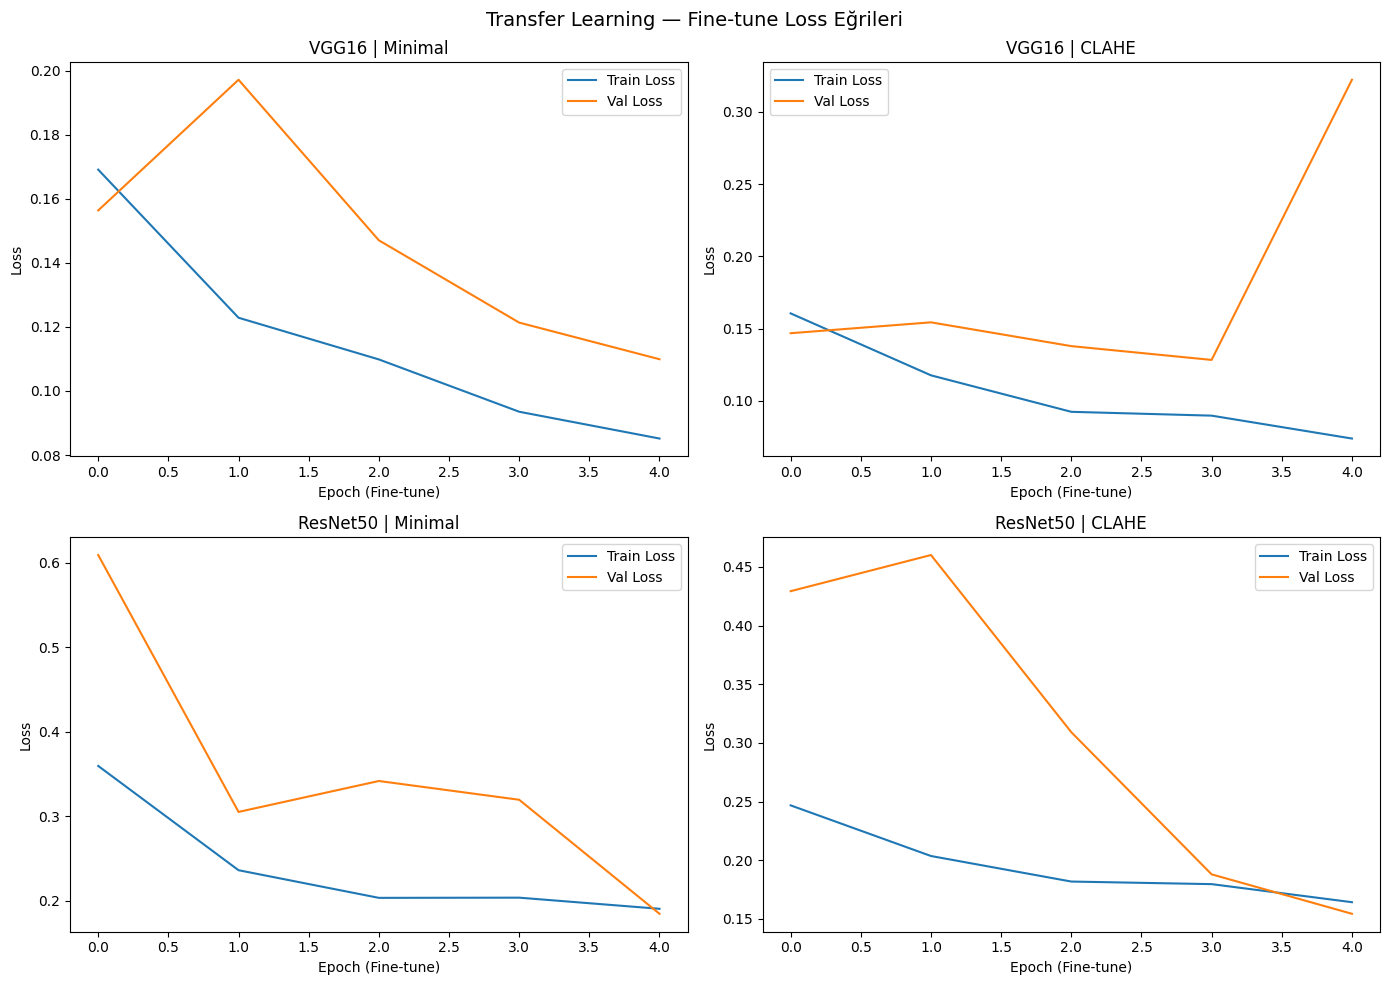

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
configs = [
    (vgg16_min_hist_ft, 'VGG16 | Minimal'),
    (vgg16_cl_hist_ft,  'VGG16 | CLAHE'),
    (rn50_min_hist_ft,  'ResNet50 | Minimal'),
    (rn50_cl_hist_ft,   'ResNet50 | CLAHE'),
]
for ax, (hist, title) in zip(axes.ravel(), configs):
    ax.plot(hist.history['loss'], label='Train Loss')
    ax.plot(hist.history['val_loss'], label='Val Loss')
    ax.set_title(title)
    ax.set_xlabel('Epoch (Fine-tune)')
    ax.set_ylabel('Loss')
    ax.legend()
plt.suptitle('Transfer Learning — Fine-tune Loss Eğrileri', fontsize=14)
plt.tight_layout()
plt.savefig('../results/figures/transfer_loss_curves.png', dpi=150)
plt.show()

## (Opsiyonel) Hibrit VGG16 + SVM

In [8]:
from models import build_hybrid_feature_extractor
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

extractor = build_hybrid_feature_extractor()

train_gen_flat = make_generator_minimal(TRAIN_DIR, augment=False, batch_size=32, shuffle=False)
test_gen_flat  = make_generator_minimal(TEST_DIR,  augment=False, batch_size=32, shuffle=False)

print('Feature vektörleri çıkarılıyor...')
X_train = extractor.predict(train_gen_flat, verbose=1)
y_train = train_gen_flat.classes

X_test  = extractor.predict(test_gen_flat, verbose=1)
y_test  = test_gen_flat.classes

print('SVM eğitiliyor...')
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train, y_train)

y_prob_svm = svm.predict_proba(X_test)[:, 1]
y_pred_svm = (y_prob_svm >= 0.5).astype(int)

hybrid_metrics = {
    'model': 'vgg16_svm',
    'preprocessing': 'minimal',
    'accuracy':  round(accuracy_score(y_test, y_pred_svm), 4),
    'f1':        round(f1_score(y_test, y_pred_svm), 4),
    'auc':       round(roc_auc_score(y_test, y_prob_svm), 4),
}
print('Hibrit VGG16+SVM:', hybrid_metrics)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Feature vektörleri çıkarılıyor...
163/163 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step
SVM eğitiliyor...
Hibrit VGG16+SVM: {'model': 'vgg16_svm', 'preprocessing': 'minimal', 'accuracy': 0.851, 'f1': 0.892, 'auc': 0.9496}
